In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.computation import align
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# 1: Data Loading & Preprocessing

## 1.A: Loading the dataset and displaying basic statistics

In [3]:
df = pd.read_csv("Datasets/BankNote_Authentication.csv")
df.head(10)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.80730,-0.44699,0
1,4.54590,8.1674,-2.45860,-1.46210,0
2,3.86600,-2.6383,1.92420,0.10645,0
3,3.45660,9.5228,-4.01120,-3.59440,0
4,0.32924,-4.4552,4.57180,-0.98880,0
5,4.36840,9.6718,-3.96060,-3.16250,0
6,3.59120,3.0129,0.72888,0.56421,0
7,2.09220,-6.8100,8.46360,-0.60216,0
8,3.20320,5.7588,-0.75345,-0.61251,0
9,1.53560,9.1772,-2.27180,-0.73535,0


In [4]:
print("Shape:", df.shape)

Shape: (1372, 5)


In [5]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [28]:
# Renaming curtosis because the spelling is wrong
df = df.rename({"curtosis": "kurtosis"}, axis="columns")

## 1.C: Missing value check

In [29]:
print("Total missing values:", df.isnull().sum().sum())

print("Missing values per column:")
df.isnull().sum()

Total missing values: 0
Missing values per column:


variance    0
skewness    0
kurtosis    0
entropy     0
class       0
dtype: int64

There are no missing values in the dataset

## 1.D: Class distribution

In [30]:
print(f'{"Class":^15}|{"Counts":^15}|{"% Count":^15}')
print('-' * 15, '+', '-' * 15, '+', '-' * 15, sep='')
for label in sorted(df["class"].unique()):
    count = (df["class"] == label).sum()
    print(f'{f"{label}":^15}|{f"{count}":^15}|{f"{count / len(df) * 100:.3f}%":^15}')

     Class     |    Counts     |    % Count    
---------------+---------------+---------------
       0       |      762      |    55.539%    
       1       |      610      |    44.461%    


0 = genuine note, 1 = forged note. The classes are balanced enough, so accuracy is a fair metric here without needing class re-weighting.

## 1.E: Graphs

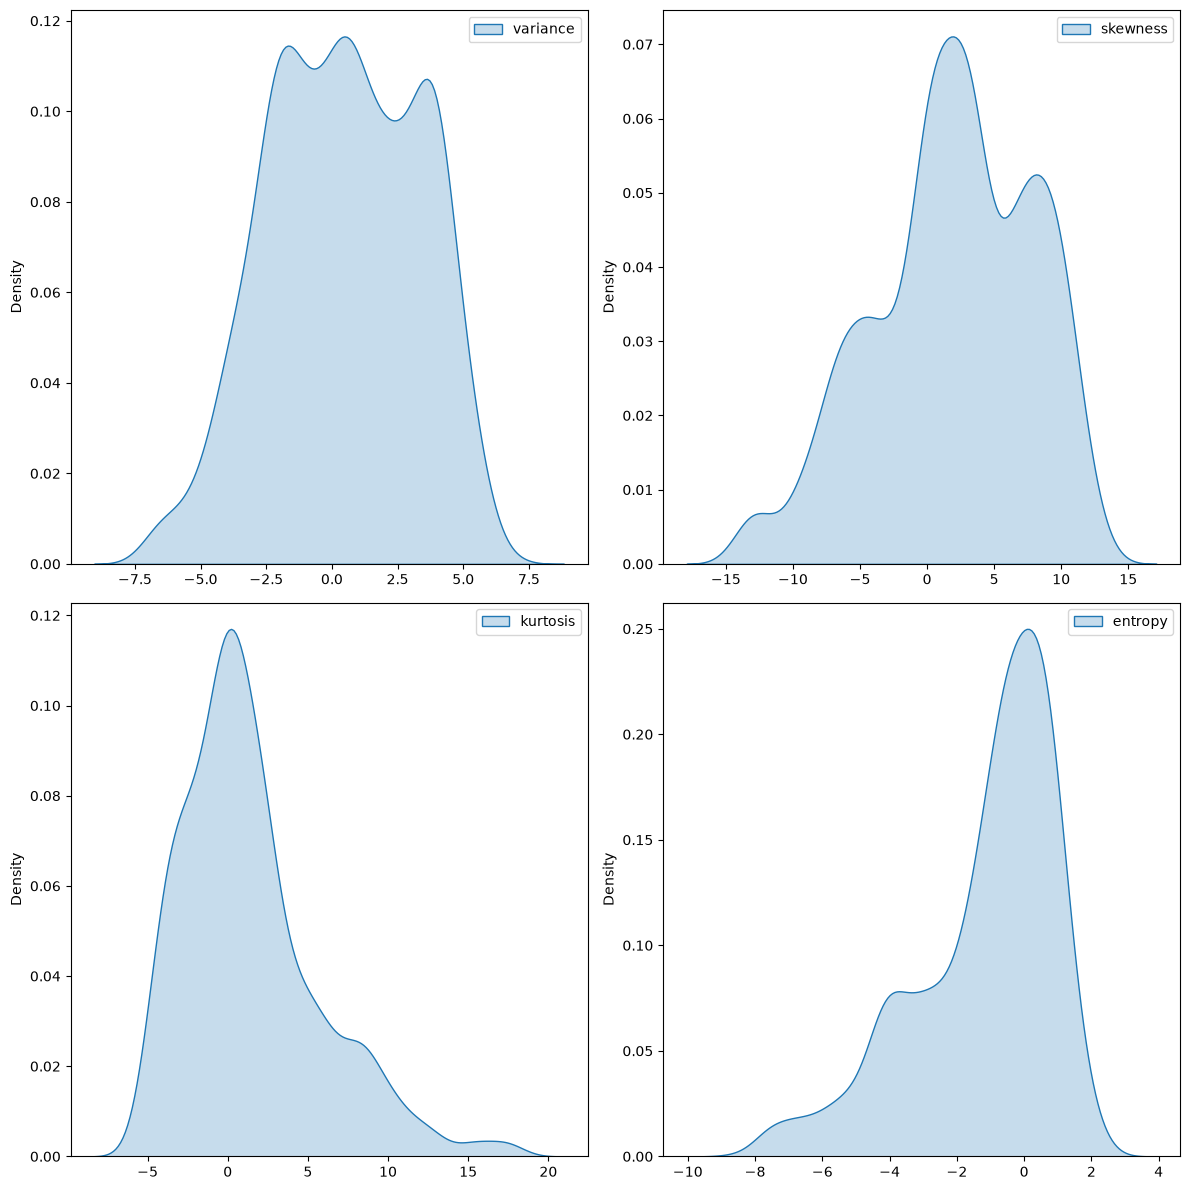

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for col, ax in zip(df.drop(columns=["class"]).columns.tolist(), axes.flatten()):
    sns.kdeplot(df[[col]], ax=ax, fill=True, color="pastel")

plt.tight_layout()
plt.show()

Variance and skewness are multimodal data while variance and entropy are unimodal

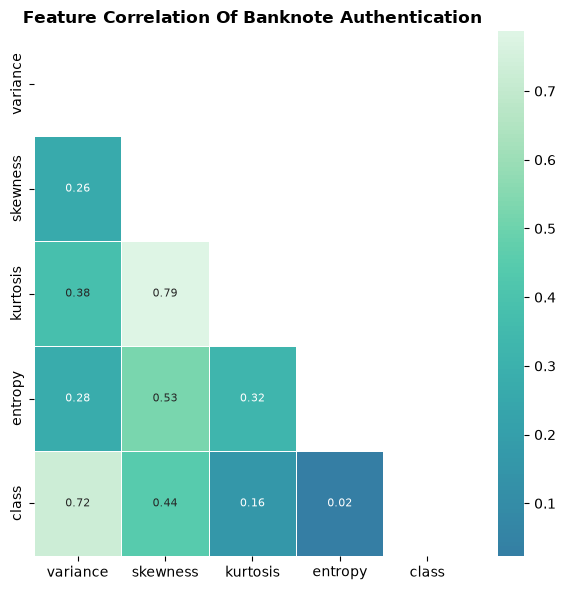

In [46]:
corr = df.corr().abs()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="mako", center=0, linewidths = 0.4, annot_kws = {"size": 8}, ax = ax)
ax.set_title("Feature Correlation Of Banknote Authentication", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

Most classes display a good enough correlation with class to be used, therefore no features will be dropped. Plus there are only 4 features so it is best to not drop any

# 2: Train/Test Split and Feature Scaling

## 2.A: Splitting

In [9]:
X = df.drop("class", axis=1).to_numpy()
y = df["class"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1097, 4)
X_test shape: (275, 4)


## 2.B: Scaling

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3: Support Vector Machine

## 3.A: Finding the best kernel

In [11]:
class_names = ["Genuine", "Forged"]

kernels = ["linear", "rbf", "poly"]
results = {}

print(f'{"Kernel":^15}|{"Accuracy":^15}')
print('-' * 15, '+', '-' * 15, sep='')

for kernel in kernels:
    classifier = SVC(kernel=kernel, random_state=42)
    classifier.fit(X_train, y_train)
    results[kernel] = accuracy_score(y_test, classifier.predict(X_test))
    print(f'{f"{kernel}":^15}|{f"{results[kernel] * 100:.2f}%":^15}')

    Kernel     |   Accuracy    
---------------+---------------
    linear     |    97.45%     
      rbf      |    100.00%    
     poly      |    98.18%     


## 3.B: Training the best kernel

In [12]:
best_kernel = max(results, key=results.get)
print("Best kernel: ", best_kernel)

svm = SVC(kernel=best_kernel, random_state=42)
svm.fit(X_train, y_train)

svm_predictions = svm.predict(X_test)
accuracy = accuracy_score(y_test, svm_predictions)

print(f"Accuracy: {accuracy * 100:.2f}%")

Best kernel:  rbf
Accuracy: 100.00%


## 3.C: Classification report and confusion matrix

In [13]:
report = classification_report(y_test, svm_predictions, target_names=class_names)
print(report)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00       153
      Forged       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



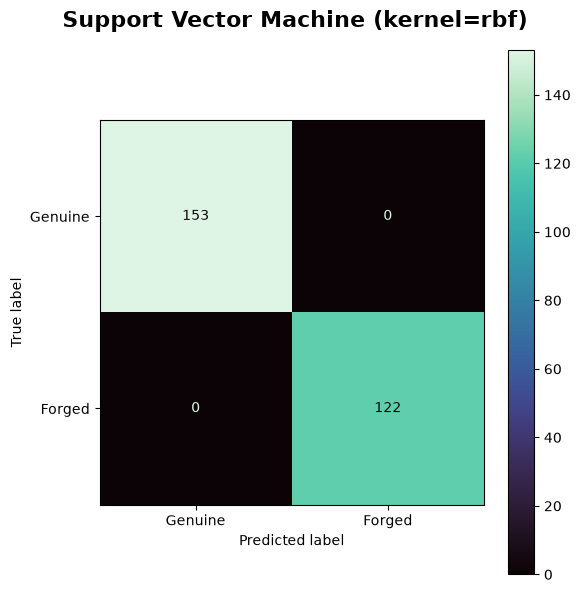

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(y_test, svm_predictions, display_labels=class_names,
                                        cmap=sns.color_palette("mako", as_cmap=True), ax=ax)
plt.suptitle(f"Support Vector Machine (kernel={best_kernel})", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# 4: Decision Tree

## 4.A: Default Decision Tree

In [15]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print(f'{"Default Decision Tree":^35}')
print()

print(f'{"Training Accuracy":^17}|{"Test Accuracy":^17}')
print('-' * 17, '+', '-' * 17, sep='')
print(f'{f"{train_acc * 100:.2f}%":^17}|{f"{test_acc * 100:.2f}%":^17}')
print()

print("Depth: ", dt.get_depth())
print("Number of leaves: ", dt.get_n_leaves())

       Default Decision Tree       

Training Accuracy|  Test Accuracy  
-----------------+-----------------
     100.00%     |     99.27%      

Depth:  7
Number of leaves:  25


The default tree has nearly equal parameters for each set, however it has a lot of leaves. The high amount of leaves is an indicator of the model taking many different paths to reach to a similar conclusion, i.e. it has memorized noise from the the training set. We will use GridSearchCV to find another model that has good accuracy and has a lower number of leaves.

## 4.B: Tuning using grid search cross-validation

In [49]:
parameter_grid = {
    "max_depth": [3, 5, 8, 10],
    "min_samples_split": [2, 5],
    "criterion": ["gini", "entropy"],
}

# Setting n_jobs = -1 allows python to use all cpu cores to train models instead of just one
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42), parameter_grid,
    cv=5, scoring="accuracy", n_jobs=-1
).fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_ * 100:.2f}%")
print(f"Best CV leaves: {grid.best_estimator_.get_n_leaves()}")

Best parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 2}
Best CV accuracy: 99.36%
Best CV leaves: 17


## 4.C: Evaluating the tuned Decision Tree

In [17]:
best_dt = grid.best_estimator_
dt_predictions = best_dt.predict(X_test)
tuned_test_acc = accuracy_score(y_test, dt_predictions)

print(f"Tuned DT Test Accuracy: {tuned_test_acc * 100:.2f}%")
print()
print(classification_report(y_test, dt_predictions, target_names=class_names))

Tuned DT Test Accuracy: 99.27%

              precision    recall  f1-score   support

     Genuine       1.00      0.99      0.99       153
      Forged       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



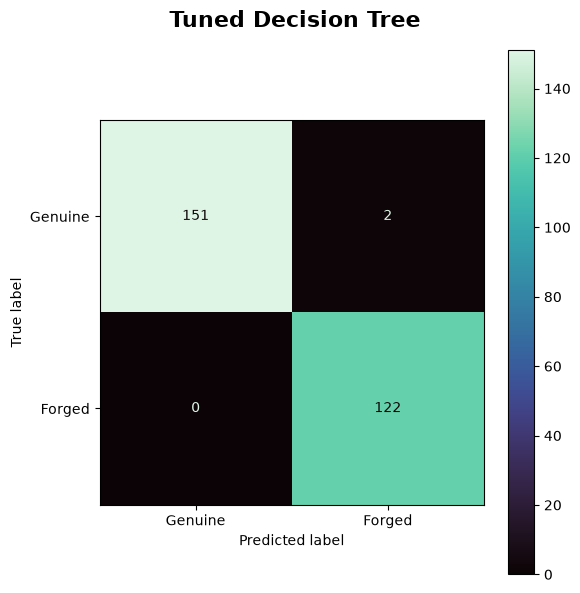

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(y_test, dt_predictions, display_labels=class_names,
                                        cmap=sns.color_palette("mako", as_cmap=True), ax=ax)
plt.suptitle("Tuned Decision Tree", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## 4.D: Visualising the tuned tree

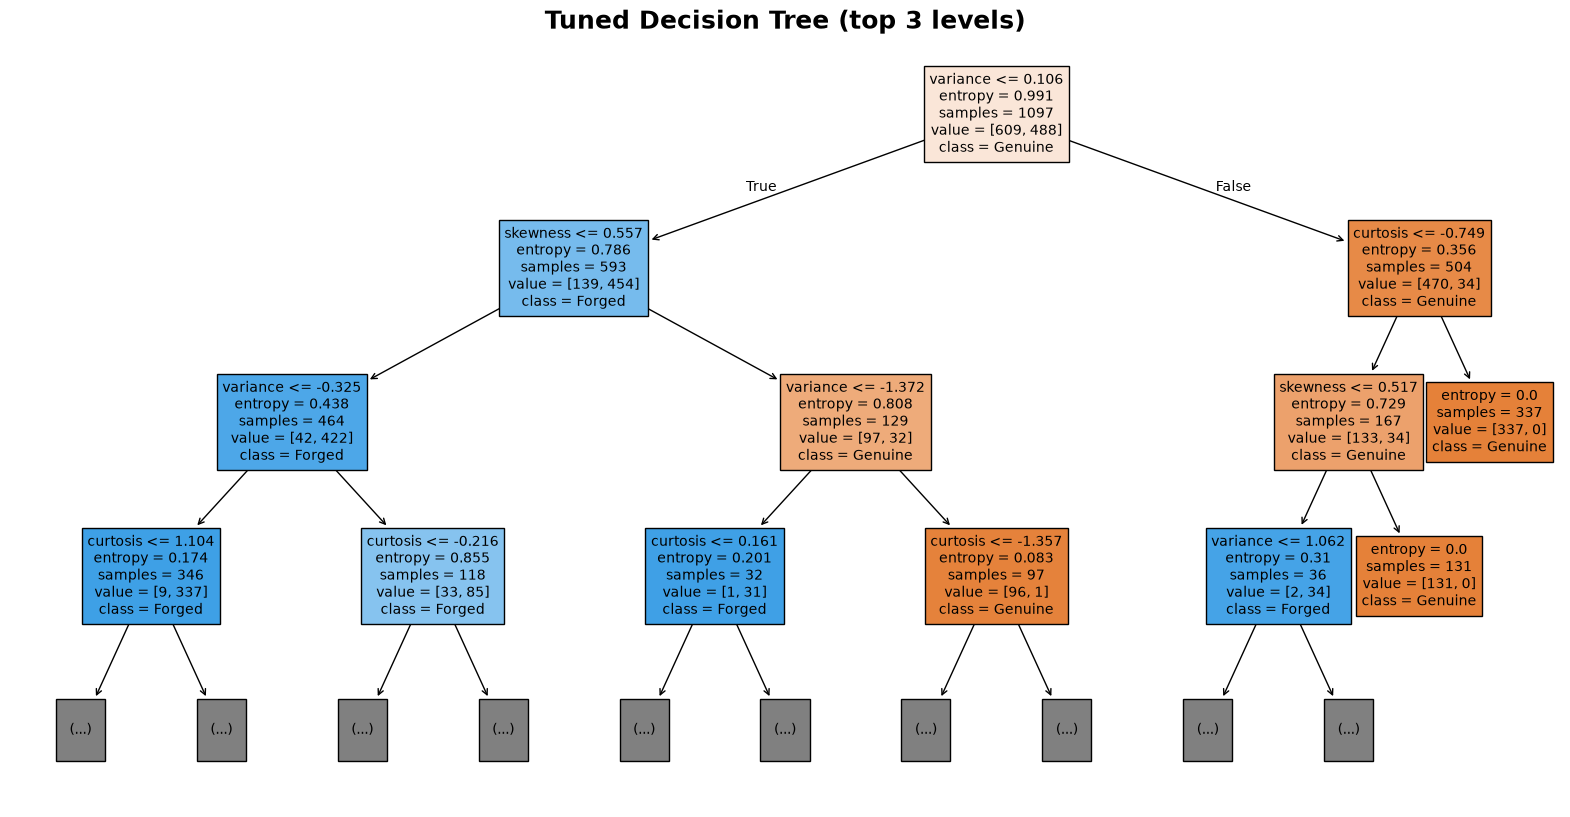

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt, max_depth=3, feature_names=df.columns[:-1], class_names=class_names,
          filled=True, fontsize=10)
plt.title("Tuned Decision Tree (top 3 levels)", fontsize=18, fontweight="bold")
plt.show()

# 5: Final Comparison

In [20]:
print(f'{"Model Type":^20}|{"Accuracy":^20}')
print("-" * 20, "+", "-" * 20, sep='')

for kernel in results.keys():
    print(f'{f"SVM + {kernel}":^20}|{f"{results[kernel] * 100:.2f}%":^20}')

print(f'{"Default DT":^20}|{f"{test_acc * 100:.2f}%":^20}')
print(f'{"Tuned DT":^20}|{f"{tuned_test_acc * 100:.2f}%":^20}')

     Model Type     |      Accuracy      
--------------------+--------------------
    SVM + linear    |       97.45%       
     SVM + rbf      |      100.00%       
     SVM + poly     |       98.18%       
     Default DT     |       99.27%       
      Tuned DT      |       99.27%       
